# EDA: ENSIA IMPACT Telegram Group Export

**Goal**: Analyze the Telegram group data to understand content structure, quality, and preprocessing needs for building a chatbot that answers questions about what was shared in the ENSIA IMPACT server.

**Data source**: `data/result.json` — Telegram export from a private supergroup with 18 topic-based channels.

## 0. Setup & Data Loading

In [1]:
import json
import re
import os
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

with open("data/result.json", encoding="utf-8") as f:
    raw = json.load(f)

chat = raw["chats"]["list"][0]
all_messages = chat["messages"]
print(f"Group: {chat['name']} ({chat['type']})")
print(f"Total messages: {len(all_messages)}")

Group: ENSIA IMPACT © Group (private_supergroup)
Total messages: 1250


In [2]:
# Build topic lookup from topic_created service messages
topic_map = {}
for m in all_messages:
    if m.get("action") == "topic_created":
        topic_map[m["id"]] = m.get("title", "Unknown")

print(f"Topics found: {len(topic_map)}")
for tid, name in topic_map.items():
    print(f"  ID {tid}: {name}")

Topics found: 18
  ID 3: Welcome board
  ID 236: Q&A
  ID 237: Research
  ID 238: Entrepreneurship
  ID 239: Startups
  ID 240: Companies
  ID 246: Freelance
  ID 273: Patents
  ID 285: Ai resources
  ID 337: Projects
  ID 554: Consulting
  ID 562: Opportunities
  ID 597: CDE - ENSIA
  ID 618: Events
  ID 805: ENSIA Incubator
  ID 865: End-of-Study Project
  ID 949: Resources by Students
  ID 1183: Students Art & Services


In [3]:
def flatten_text(text_field):
    """Flatten Telegram's polymorphic text field into a plain string."""
    if isinstance(text_field, str):
        return text_field
    if isinstance(text_field, list):
        parts = []
        for item in text_field:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(item.get("text", ""))
        return "".join(parts)
    return ""


def extract_links(text_field):
    """Extract URLs from text_entities or list-type text."""
    links = []
    if isinstance(text_field, list):
        for item in text_field:
            if isinstance(item, dict) and item.get("type") in ("link", "text_link"):
                url = item.get("href", item.get("text", ""))
                if url:
                    links.append(url)
    return links


def get_reaction_count(msg):
    """Sum all reaction counts for a message."""
    reactions = msg.get("reactions", [])
    return sum(r.get("count", 0) for r in reactions)


def resolve_topic(msg, all_msgs_by_id):
    """Resolve a message's topic by tracing reply_to_message_id chain."""
    visited = set()
    current = msg
    while current:
        rid = current.get("reply_to_message_id")
        if rid is None:
            return None
        if rid in topic_map:
            return topic_map[rid]
        if rid in visited:
            return None
        visited.add(rid)
        current = all_msgs_by_id.get(rid)
    return None


# Index all messages by ID for reply chain resolution
msgs_by_id = {m["id"]: m for m in all_messages}

# Separate content vs service messages
content_msgs = [m for m in all_messages if m["type"] == "message"]
service_msgs = [m for m in all_messages if m["type"] == "service"]
print(f"Content messages: {len(content_msgs)}")
print(f"Service messages: {len(service_msgs)}")

Content messages: 410
Service messages: 840


In [4]:
# Build the main DataFrame from content messages
rows = []
for m in content_msgs:
    text_clean = flatten_text(m.get("text", ""))
    links = extract_links(m.get("text", ""))
    # Also check text_entities for links
    for ent in m.get("text_entities", []):
        if ent.get("type") in ("link", "text_link"):
            url = ent.get("href", ent.get("text", ""))
            if url and url not in links:
                links.append(url)

    rows.append({
        "id": m["id"],
        "date": pd.to_datetime(m["date"]),
        "sender": m.get("from", m.get("actor", "Unknown")),
        "sender_id": m.get("from_id", m.get("actor_id", "")),
        "text_raw": m.get("text", ""),
        "text_clean": text_clean,
        "text_length": len(text_clean),
        "topic": resolve_topic(m, msgs_by_id),
        "has_photo": "photo" in m,
        "has_file": "file" in m,
        "file_name": m.get("file_name", None),
        "mime_type": m.get("mime_type", None),
        "reaction_count": get_reaction_count(m),
        "links": links,
        "link_count": len(links),
        "is_edited": "edited" in m,
        "is_forwarded": "forwarded_from" in m,
        "reply_to": m.get("reply_to_message_id"),
    })

df = pd.DataFrame(rows)
df["month"] = df["date"].dt.to_period("M")
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.day_name()

print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (410, 21)


,id,date,sender,sender_id,text_raw,text_clean,text_length,topic,has_photo,has_file,...,mime_type,reaction_count,links,link_count,is_edited,is_forwarded,reply_to,month,hour,day_of_week
0,4,2024-09-21 13:47:30,Wahid Chami ENSIA,user5365934951,Welcome to all those who believe in themselves...,Welcome to all those who believe in themselves...,66,Welcome board,False,False,...,NaN,58,[],0,True,False,3.0,2024-09,13,Saturday
1,11,2024-09-21 14:17:02,Taha Medj,user6270123692,Let the chat begin,Let the chat begin,18,NaN,False,False,...,NaN,0,[],0,False,False,NaN,2024-09,14,Saturday
2,247,2024-09-21 19:28:52,Wahid Chami ENSIA,user5365934951,"[This is the official channel of EI ""ENSIA IMP...","This is the official channel of EI ""ENSIA IMPA...",81,NaN,False,False,...,NaN,0,[https://t.me/+kjgwZa-i6eAzYTdk],1,False,False,NaN,2024-09,19,Saturday
3,303,2024-09-22 10:20:57,ENSIA IMPACT © Group,channel2482670091,"Good morning everyone, and welcome to this cha...","Good morning everyone, and welcome to this cha...",231,Companies,False,False,...,NaN,18,[],0,True,False,240.0,2024-09,10,Sunday
4,305,2024-09-22 10:23:07,ENSIA IMPACT © Group,channel2482670091,"[First of all, you will find below a list of c...","First of all, you will find below a list of co...",234,Companies,False,False,...,NaN,27,[https://docs.google.com/spreadsheets/d/1_eqZK...,1,True,False,240.0,2024-09,10,Sunday


## 1. Message Type Distribution

How much of the data is actual content vs. service noise (joins, leaves, etc.)?

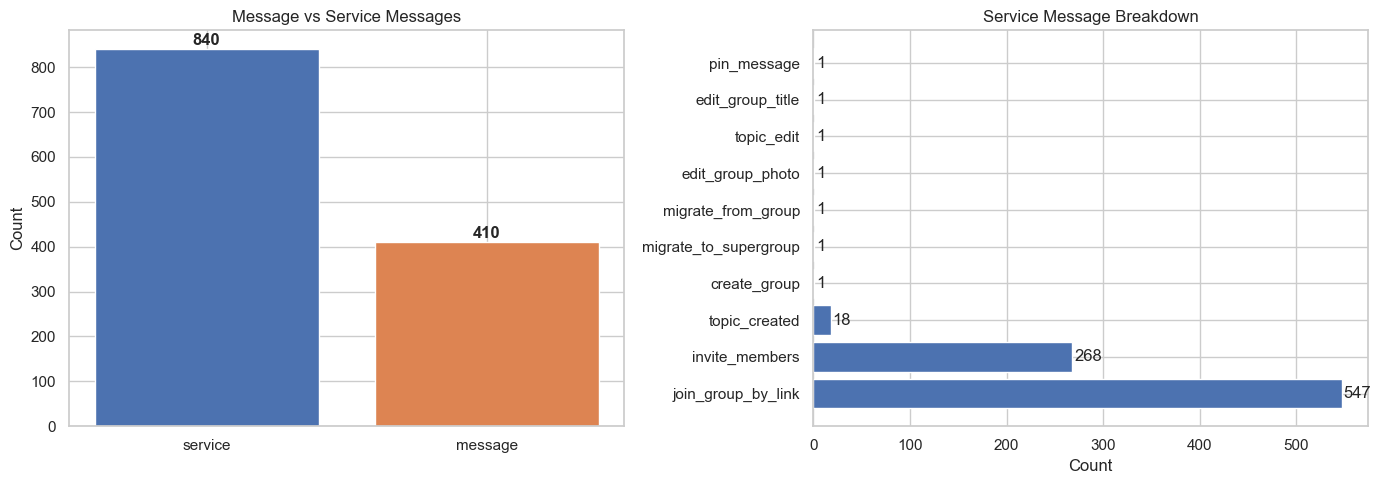


→ Only 33% of messages are usable content. The rest are join/leave service events.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Message vs Service split
type_counts = Counter(m["type"] for m in all_messages)
axes[0].bar(type_counts.keys(), type_counts.values(), color=["#4C72B0", "#DD8452"])
axes[0].set_title("Message vs Service Messages")
axes[0].set_ylabel("Count")
for i, (k, v) in enumerate(type_counts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Service action breakdown
action_counts = Counter(m.get("action", "unknown") for m in service_msgs)
actions_sorted = action_counts.most_common()
labels = [a[0] for a in actions_sorted]
values = [a[1] for a in actions_sorted]
axes[1].barh(labels, values, color="#4C72B0")
axes[1].set_title("Service Message Breakdown")
axes[1].set_xlabel("Count")
for i, v in enumerate(values):
    axes[1].text(v + 2, i, str(v), va="center")

plt.tight_layout()
plt.show()

content_pct = len(content_msgs) / len(all_messages) * 100
print(f"\n→ Only {content_pct:.0f}% of messages are usable content. The rest are join/leave service events.")

## 2. Topic / Channel Analysis

The group uses Telegram's topic feature to organize content into 18 channels. This is critical for chatbot routing — understanding which topics have enough content to support Q&A.

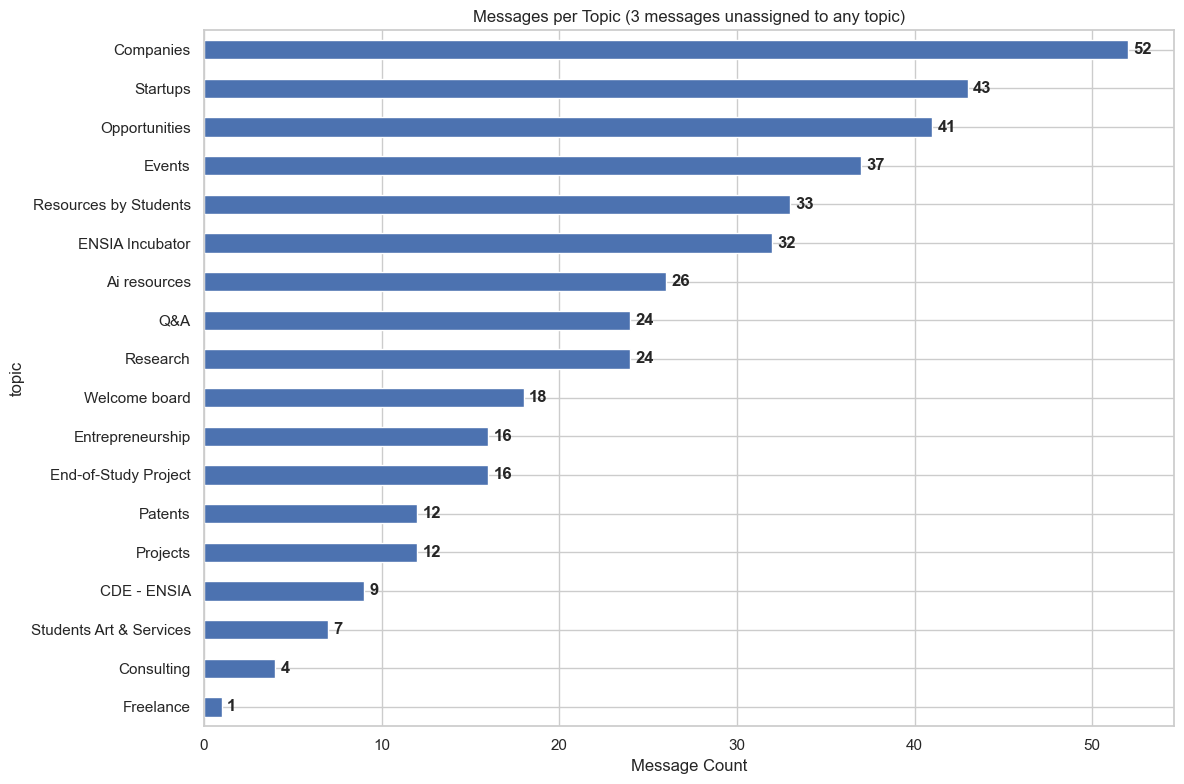


Thin topics (< 5 messages):
  Consulting: 4
  Freelance: 1

Rich topics (>= 20 messages):
  Companies: 52
  Startups: 43
  Opportunities: 41
  Events: 37
  Resources by Students: 33
  ENSIA Incubator: 32
  Ai resources: 26
  Q&A: 24
  Research: 24


In [6]:
# Messages per topic
topic_counts = df["topic"].value_counts()
unassigned = df["topic"].isna().sum()

fig, ax = plt.subplots(figsize=(12, 8))
topic_counts.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title(f"Messages per Topic ({unassigned} messages unassigned to any topic)")
ax.set_xlabel("Message Count")
for i, (idx, v) in enumerate(topic_counts.sort_values().items()):
    ax.text(v + 0.3, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nThin topics (< 5 messages):")
for topic, count in topic_counts.items():
    if count < 5:
        print(f"  {topic}: {count}")
print(f"\nRich topics (>= 20 messages):")
for topic, count in topic_counts.items():
    if count >= 20:
        print(f"  {topic}: {count}")

In [7]:
# Per-topic stats table
topic_df = df[df["topic"].notna()].copy()

topic_stats = topic_df.groupby("topic").agg(
    messages=("id", "count"),
    median_length=("text_length", "median"),
    total_chars=("text_length", "sum"),
    photos=("has_photo", "sum"),
    files=("has_file", "sum"),
    total_links=("link_count", "sum"),
    avg_reactions=("reaction_count", "mean"),
).sort_values("messages", ascending=False)

topic_stats["median_length"] = topic_stats["median_length"].astype(int)
topic_stats["avg_reactions"] = topic_stats["avg_reactions"].round(1)
topic_stats["photo_pct"] = (topic_stats["photos"] / topic_stats["messages"] * 100).round(0).astype(int)

# Flag topics that are heavily photo-based (chatbot can't answer from photos without OCR)
print("⚠️  Photo-heavy topics (>50% of messages contain photos — likely needs OCR for chatbot):")
photo_heavy = topic_stats[topic_stats["photo_pct"] > 50]
for topic, row in photo_heavy.iterrows():
    print(f"   {topic}: {row['photos']}/{row['messages']} photos ({row['photo_pct']}%), median text = {row['median_length']} chars")

print("\n⚠️  Topics where median text length is 0 (mostly media-only):")
text_poor = topic_stats[topic_stats["median_length"] == 0]
for topic, row in text_poor.iterrows():
    print(f"   {topic}: {row['messages']} messages, all photo-driven")

topic_stats

⚠️  Photo-heavy topics (>50% of messages contain photos — likely needs OCR for chatbot):
   Opportunities: 23.0/41.0 photos (56.0%), median text = 251.0 chars
   Events: 23.0/37.0 photos (62.0%), median text = 347.0 chars
   Q&A: 17.0/24.0 photos (71.0%), median text = 0.0 chars

⚠️  Topics where median text length is 0 (mostly media-only):
   Q&A: 24.0 messages, all photo-driven


,messages,median_length,total_chars,photos,files,total_links,avg_reactions,photo_pct
topic,,,,,,,,
Companies,52,172,10710,18,1,7,13.9,35
Startups,43,155,10187,15,6,23,5.4,35
Opportunities,41,251,9670,23,0,30,7.2,56
Events,37,347,12081,23,0,31,5.9,62
Resources by Students,33,345,12756,3,0,30,17.5,9
ENSIA Incubator,32,436,13295,7,0,22,14.1,22
Ai resources,26,211,6283,6,0,18,11.9,23
Q&A,24,0,1524,17,0,3,4.0,71
Research,24,157,5501,5,2,8,9.2,21


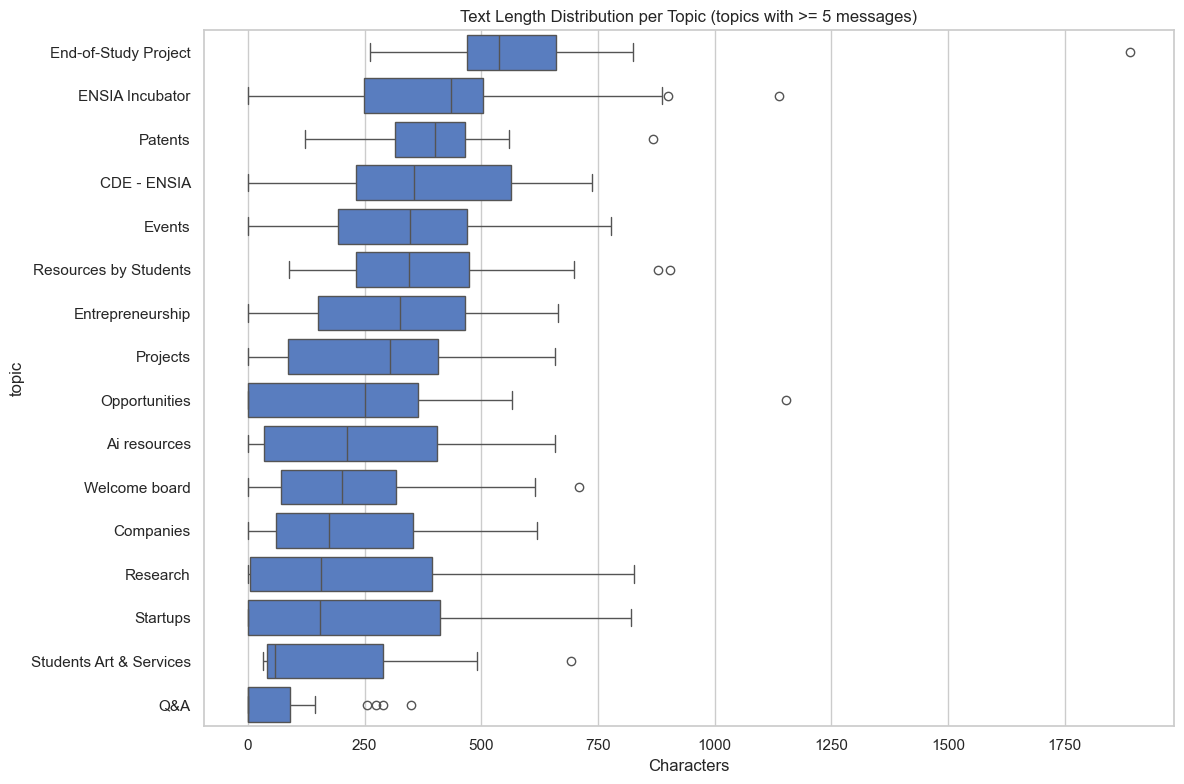

In [8]:
# Text length distribution per topic (box plot)
topics_with_enough = topic_stats[topic_stats["messages"] >= 5].index.tolist()
plot_df = topic_df[topic_df["topic"].isin(topics_with_enough)]

fig, ax = plt.subplots(figsize=(12, 8))
order = plot_df.groupby("topic")["text_length"].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, y="topic", x="text_length", order=order, ax=ax)
ax.set_title("Text Length Distribution per Topic (topics with >= 5 messages)")
ax.set_xlabel("Characters")
plt.tight_layout()
plt.show()

## 3. Temporal Analysis

When was the group most active? Is content spread evenly or concentrated in bursts?

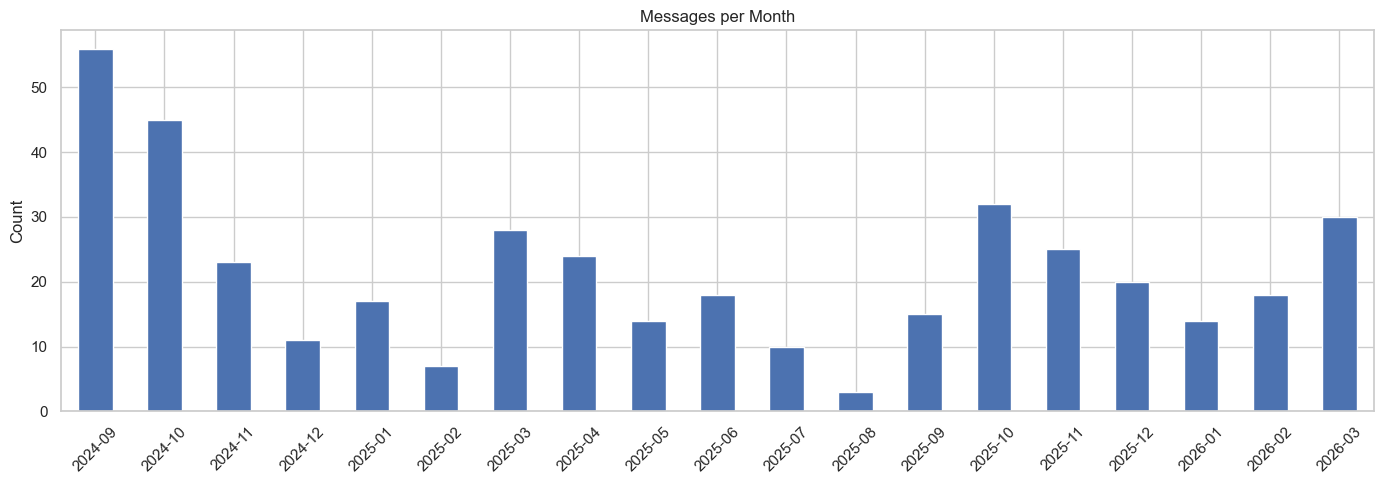

Date range: 2024-09-21 to 2026-03-28
Active months: 19


In [9]:
# Monthly message volume
monthly = df.groupby("month").size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Messages per Month")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Active months: {len(monthly)}")

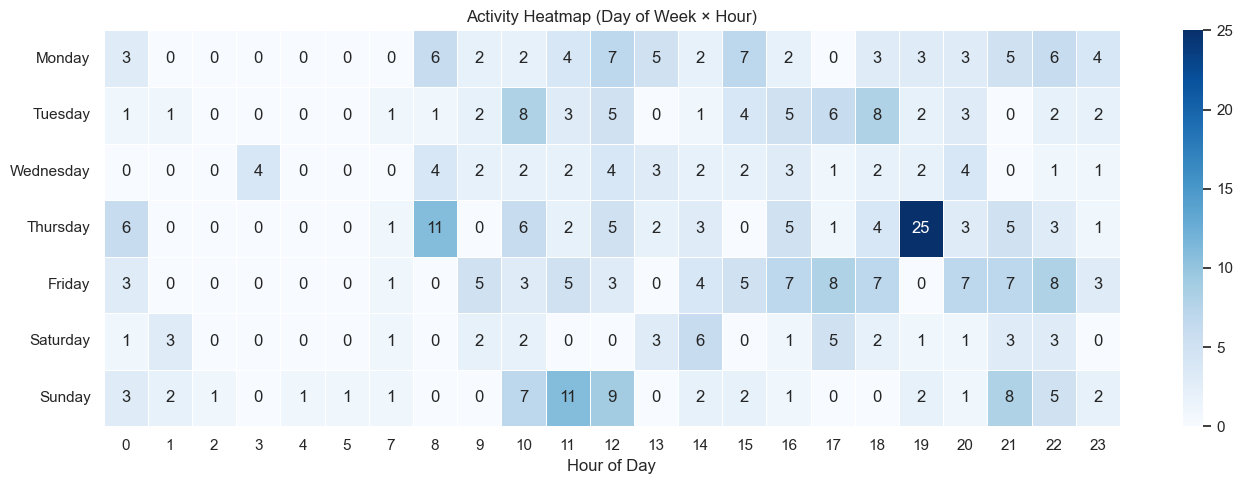

In [10]:
# Activity heatmap: day of week × hour
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = df.groupby(["day_of_week", "hour"]).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap="Blues", annot=True, fmt="d", ax=ax, linewidths=0.5)
ax.set_title("Activity Heatmap (Day of Week × Hour)")
ax.set_ylabel("")
ax.set_xlabel("Hour of Day")
plt.tight_layout()
plt.show()

## 4. Sender Analysis

Who produces the content? Admin-posted content is likely more curated and authoritative for the chatbot.

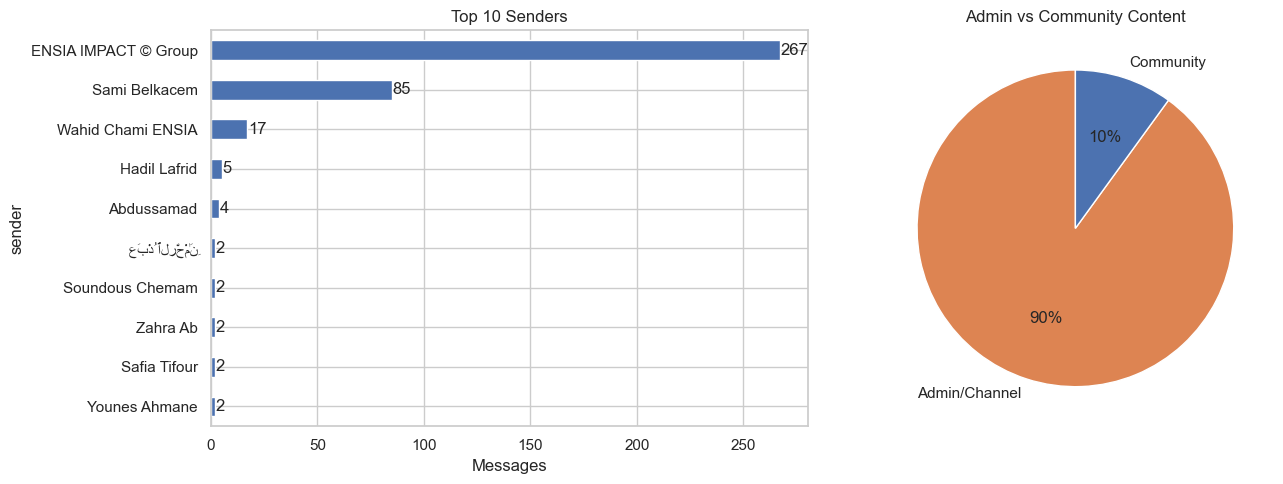


Total unique senders: 30
Admin content: 369 msgs (90%)
Community content: 41 msgs (10%)


In [11]:
# Top senders
sender_counts = df["sender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 senders bar chart
top10 = sender_counts.head(10)
top10.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Senders")
axes[0].set_xlabel("Messages")
for i, (idx, v) in enumerate(top10.sort_values().items()):
    axes[0].text(v + 0.3, i, str(v), va="center")

# Admin vs community
admin_names = {"ENSIA IMPACT © Group", "Wahid Chami ENSIA", "Sami Belkacem"}
df["is_admin"] = df["sender"].isin(admin_names)
admin_split = df["is_admin"].value_counts()
admin_split.index = ["Community" if not x else "Admin/Channel" for x in admin_split.index]
axes[1].pie(admin_split.values, labels=admin_split.index, autopct="%1.0f%%",
            colors=["#DD8452", "#4C72B0"], startangle=90)
axes[1].set_title("Admin vs Community Content")

plt.tight_layout()
plt.show()

print(f"\nTotal unique senders: {len(sender_counts)}")
print(f"Admin content: {df['is_admin'].sum()} msgs ({df['is_admin'].mean()*100:.0f}%)")
print(f"Community content: {(~df['is_admin']).sum()} msgs ({(~df['is_admin']).mean()*100:.0f}%)")

## 5. Text Content Analysis

The most critical section for the chatbot — understanding content quality, languages, and themes.

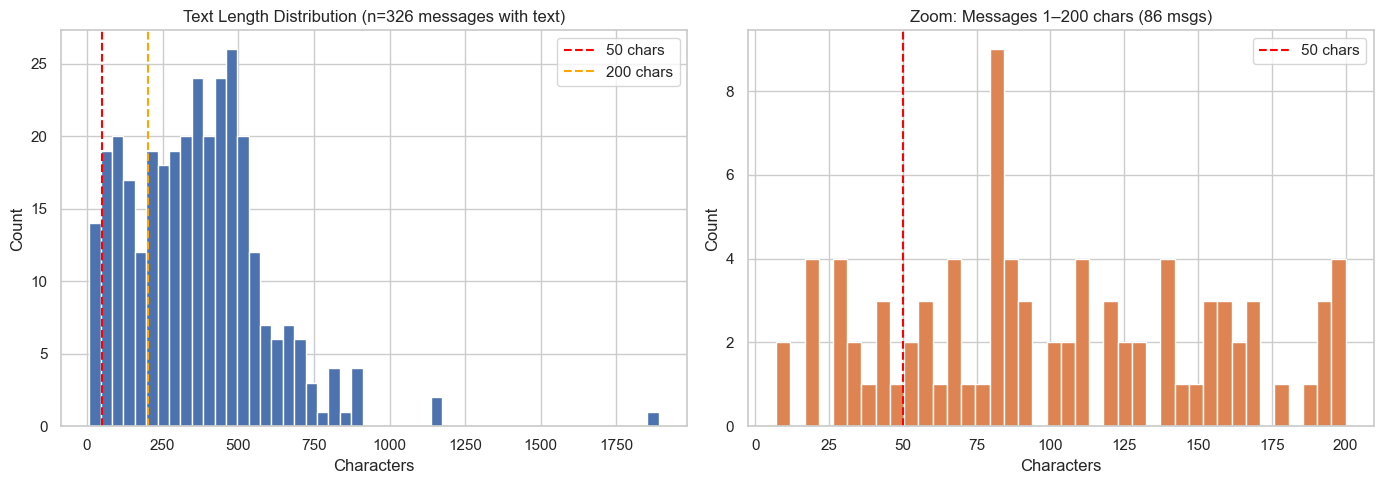

Empty (media-only or no content): 84
Short non-empty (1–49 chars):     17
Medium (50–199 chars):            68
Long (>= 200 chars):              241
Total:                            410


In [12]:
# Text length distribution (excluding media-only messages with 0 text)
text_only = df[df["text_length"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(text_only["text_length"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(50, color="red", linestyle="--", label="50 chars")
axes[0].axvline(200, color="orange", linestyle="--", label="200 chars")
axes[0].set_title(f"Text Length Distribution (n={len(text_only)} messages with text)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].legend()

# Zoom into shorter messages
short = text_only[text_only["text_length"] <= 200]
axes[1].hist(short["text_length"], bins=40, color="#DD8452", edgecolor="white")
axes[1].axvline(50, color="red", linestyle="--", label="50 chars")
axes[1].set_title(f"Zoom: Messages 1–200 chars ({len(short)} msgs)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

empty = (df["text_length"] == 0).sum()
short_nonempty = ((df["text_length"] > 0) & (df["text_length"] < 50)).sum()
medium = ((df["text_length"] >= 50) & (df["text_length"] < 200)).sum()
long = (df["text_length"] >= 200).sum()
print(f"Empty (media-only or no content): {empty}")
print(f"Short non-empty (1–49 chars):     {short_nonempty}")
print(f"Medium (50–199 chars):            {medium}")
print(f"Long (>= 200 chars):              {long}")
print(f"Total:                            {empty + short_nonempty + medium + long}")

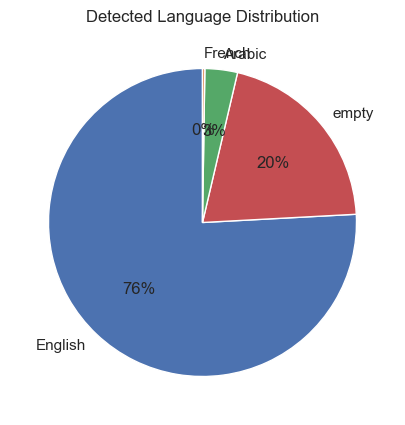

English: 311 messages
empty: 84 messages
Arabic: 14 messages
French: 1 messages


In [13]:
# Language detection (heuristic)
def detect_language(text):
    if not text:
        return "empty"
    if re.search(r"[؀-ۿ]", text):
        return "Arabic"
    french_words = {"bonjour", "merci", "les", "des", "est", "pour", "dans", "une", "avec", "sur",
                    "que", "qui", "nous", "vous", "pas", "sont", "cette", "aux", "par", "ont"}
    words = set(text.lower().split())
    french_matches = len(words & french_words)
    if french_matches >= 2:
        return "French"
    return "English"

df["language"] = df["text_clean"].apply(detect_language)

fig, ax = plt.subplots(figsize=(7, 5))
lang_counts = df["language"].value_counts()
colors = {"English": "#4C72B0", "French": "#DD8452", "Arabic": "#55A868", "empty": "#C44E52"}
ax.pie(lang_counts.values, labels=lang_counts.index, autopct="%1.0f%%",
       colors=[colors.get(l, "#999") for l in lang_counts.index], startangle=90)
ax.set_title("Detected Language Distribution")
plt.show()

for lang in lang_counts.index:
    print(f"{lang}: {lang_counts[lang]} messages")

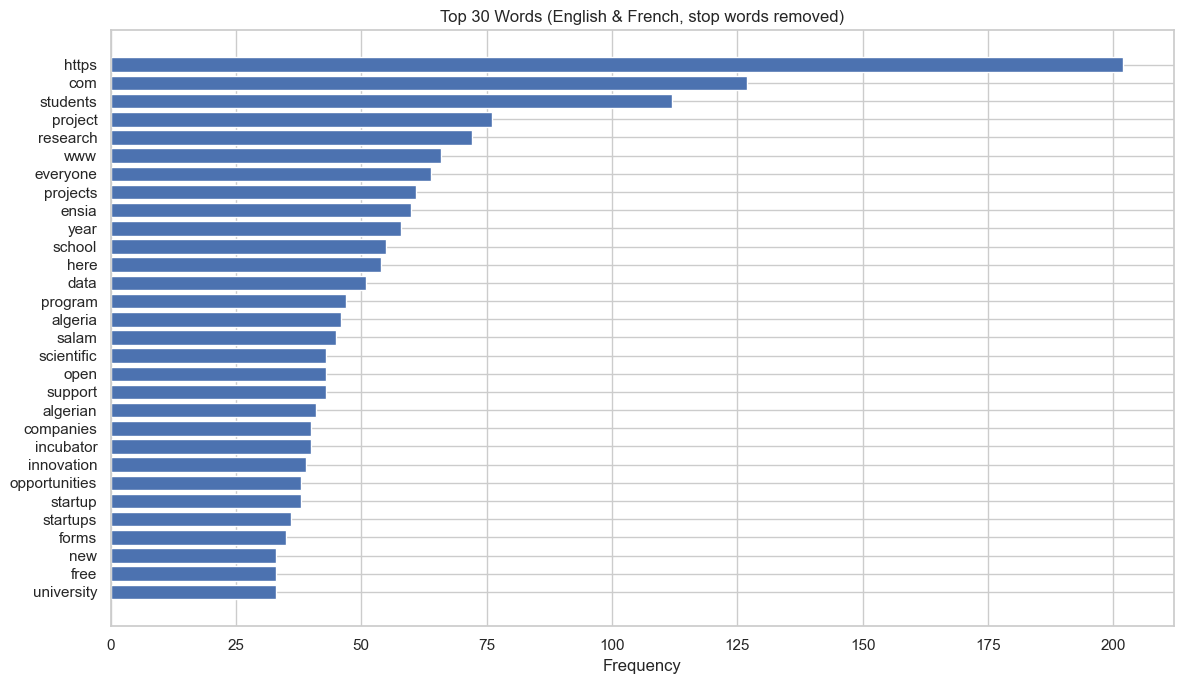

In [14]:
# Word frequency analysis
stop_words = {
    "the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "do", "does", "did", "will", "would", "could",
    "should", "may", "might", "shall", "can", "to", "of", "in", "for",
    "on", "with", "at", "by", "from", "as", "into", "through", "during",
    "before", "after", "above", "below", "between", "out", "off", "over",
    "under", "again", "further", "then", "once", "and", "but", "or", "nor",
    "not", "so", "than", "too", "very", "just", "about", "up", "it", "its",
    "this", "that", "these", "those", "i", "me", "my", "we", "our", "you",
    "your", "he", "him", "his", "she", "her", "they", "them", "their",
    "what", "which", "who", "whom", "how", "when", "where", "why",
    "all", "each", "every", "both", "few", "more", "most", "other",
    "some", "such", "no", "only", "own", "same", "if", "also",
    # French stop words
    "le", "la", "les", "de", "des", "du", "un", "une", "et", "est",
    "en", "que", "qui", "dans", "pour", "par", "sur", "au", "aux",
    "avec", "ce", "se", "ne", "pas", "son", "sa", "ses", "il", "elle",
    "nous", "vous", "ils", "elles", "ou", "mais",
}

all_text = " ".join(df[df["text_length"] > 0]["text_clean"])
words = re.findall(r"[a-zA-ZÀ-ÿ]{3,}", all_text.lower())
filtered = [w for w in words if w not in stop_words]
word_freq = Counter(filtered).most_common(30)

fig, ax = plt.subplots(figsize=(12, 7))
words_list = [w[0] for w in word_freq]
counts_list = [w[1] for w in word_freq]
ax.barh(words_list[::-1], counts_list[::-1], color="#4C72B0")
ax.set_title("Top 30 Words (English & French, stop words removed)")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

Total links found: 221
Messages with links: 187


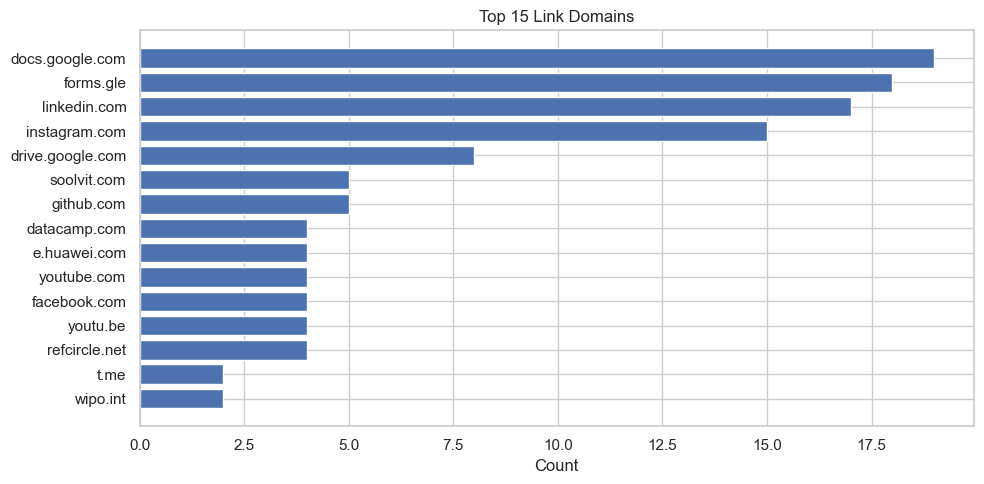

In [15]:
# Link analysis
links_df = df[df["link_count"] > 0]
all_links = [link for links in df["links"] for link in links]
print(f"Total links found: {len(all_links)}")
print(f"Messages with links: {len(links_df)}")

# Categorize links by domain
def get_domain(url):
    match = re.search(r"(?:https?://)?(?:www\.)?([^/]+)", url)
    return match.group(1) if match else url

domain_counts = Counter(get_domain(link) for link in all_links).most_common(15)
if domain_counts:
    fig, ax = plt.subplots(figsize=(10, 5))
    domains = [d[0] for d in domain_counts]
    dcounts = [d[1] for d in domain_counts]
    ax.barh(domains[::-1], dcounts[::-1], color="#4C72B0")
    ax.set_title("Top 15 Link Domains")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No links with recognizable domains found.")

## 6. Media & File Inventory

What files and photos were shared? These are content the chatbot may need to reference but can't directly read without extraction.

Messages with files: 13



,sender,topic,file_name,mime_type,text_length,has_caption
13,ENSIA IMPACT © Group,Research,Research-Lab-Reports-IMRAD.pdf,application/pdf,0,False
50,ENSIA IMPACT © Group,Startups,Arrêté 1275.pdf,application/pdf,0,False
52,ENSIA IMPACT © Group,Startups,اليات تنفيذ مشروع القرار 1275.pdf,application/pdf,0,False
71,ENSIA IMPACT © Group,Startups,دليل_مشروع_للحصول_على_شهادة_مؤسسة_ناشئة.pdf,application/pdf,0,False
78,Wahid Chami ENSIA,Research,A2023078 (1).pdf,application/pdf,0,False
97,Wahid Chami ENSIA,CDE - ENSIA,A2024070.pdf,application/pdf,0,False
158,ENSIA IMPACT © Group,Startups,Arreté 008.pdf,application/pdf,0,False
194,ENSIA IMPACT © Group,Startups,Startup_Factory[1] (1).pdf,application/pdf,0,False
239,Sami Belkacem,Companies,Internship Analysis.pdf,application/pdf,563,True
292,Sami Belkacem,Startups,The Ultimate Guide to Pitch Decks for Entrepre...,application/pdf,0,False



Photos total: 135
  With caption text: 61
  Photo-only (no text): 74 — these are content gaps for a text chatbot


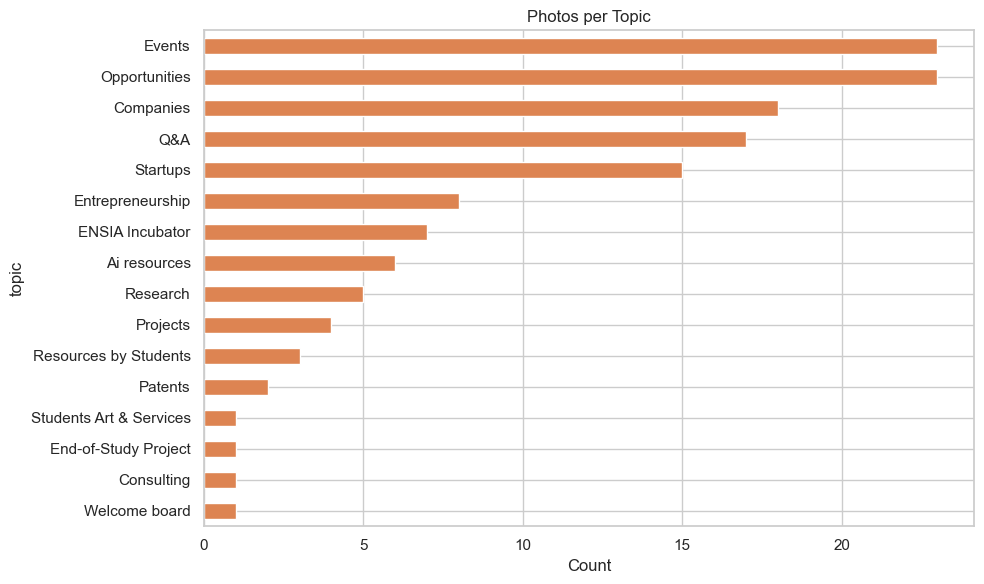

In [16]:
# Files shared in the group
file_msgs = df[df["has_file"]].copy()
print(f"Messages with files: {len(file_msgs)}\n")

if len(file_msgs) > 0:
    file_info = file_msgs[["sender", "topic", "file_name", "mime_type", "text_length"]].copy()
    file_info["has_caption"] = file_info["text_length"] > 0
    display(file_info)

# Photos
photo_msgs = df[df["has_photo"]].copy()
photo_only = photo_msgs[photo_msgs["text_length"] == 0]
photo_with_caption = photo_msgs[photo_msgs["text_length"] > 0]

print(f"\nPhotos total: {len(photo_msgs)}")
print(f"  With caption text: {len(photo_with_caption)}")
print(f"  Photo-only (no text): {len(photo_only)} — these are content gaps for a text chatbot")

# Photos per topic
if len(photo_msgs) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    photo_topics = photo_msgs["topic"].value_counts()
    photo_topics.sort_values().plot.barh(ax=ax, color="#DD8452")
    ax.set_title("Photos per Topic")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()

## 7. Reactions as Quality Signal

Messages with more reactions are likely more valuable/useful. This can help the chatbot prioritize answers.

Messages with reactions: 328 / 410 (80%)
Reaction count stats:
count    328.000000
mean      14.039634
std       11.551041
min        1.000000
25%        7.000000
50%       11.000000
75%       18.000000
max       87.000000


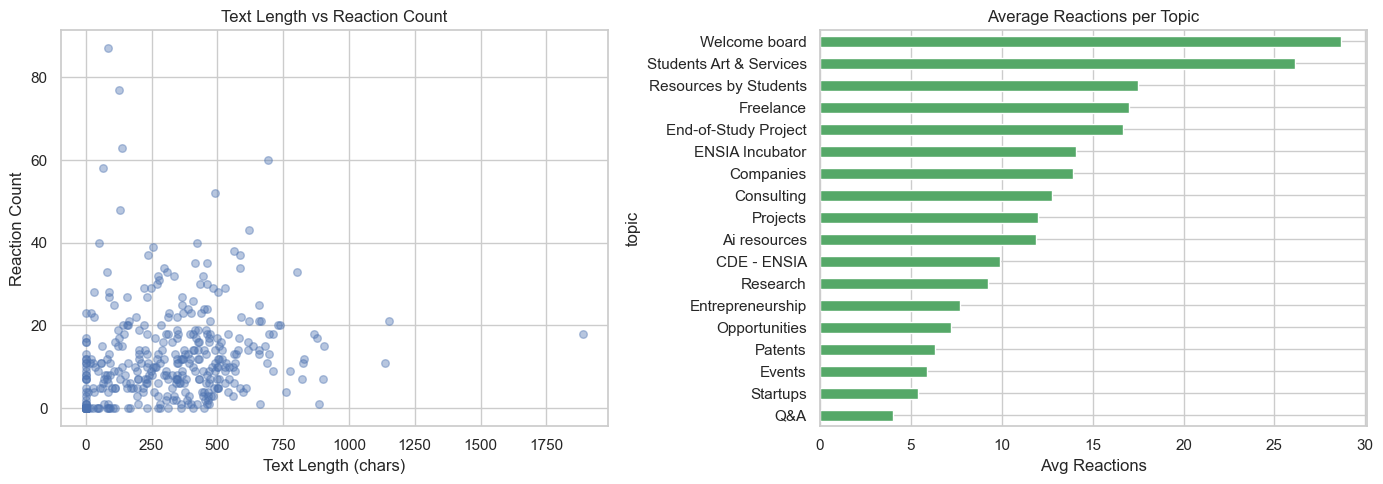

In [17]:
# Reactions overview
reacted = df[df["reaction_count"] > 0]
print(f"Messages with reactions: {len(reacted)} / {len(df)} ({len(reacted)/len(df)*100:.0f}%)")
print(f"Reaction count stats:")
print(reacted["reaction_count"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: text length vs reactions
axes[0].scatter(df["text_length"], df["reaction_count"], alpha=0.4, color="#4C72B0", s=30)
axes[0].set_title("Text Length vs Reaction Count")
axes[0].set_xlabel("Text Length (chars)")
axes[0].set_ylabel("Reaction Count")

# Average reactions per topic
if len(topic_df) > 0:
    topic_reactions = topic_df.groupby("topic")["reaction_count"].mean().sort_values()
    topic_reactions.plot.barh(ax=axes[1], color="#55A868")
    axes[1].set_title("Average Reactions per Topic")
    axes[1].set_xlabel("Avg Reactions")

plt.tight_layout()
plt.show()

In [18]:
# Top 10 most-reacted messages
top_reacted = df.nlargest(10, "reaction_count")[["sender", "topic", "reaction_count", "text_clean"]].copy()
top_reacted["text_preview"] = top_reacted["text_clean"].str[:120] + "..."
top_reacted[["sender", "topic", "reaction_count", "text_preview"]]

,sender,topic,reaction_count,text_preview
230,Sami Belkacem,Welcome board,87,Aidkoum Moubarak to the ENSIA Impact community...
399,ENSIA IMPACT © Group,Welcome board,77,عيدكم مبارك لكل أعضاء ENSIA Impact community 🎉...
362,ENSIA IMPACT © Group,Resources by Students,63,طالب من المدرسة يودّ أن يشارك قراءته الكاملة ل...
294,Sami Belkacem,Students Art & Services,60,🎨 Welcome to Students Art & Services! 💫\n\nSal...
0,Wahid Chami ENSIA,Welcome board,58,Welcome to all those who believe in themselves...
325,ENSIA IMPACT © Group,Students Art & Services,52,We're happy to share that Djamel Delivery made...
186,ENSIA IMPACT © Group,ENSIA Incubator,48,عيدكم مبارك، تقبل الله منا ومنكم صالح الأعمال....
310,Sami Belkacem,Companies,43,The partnership with Ooredoo was officially fo...
231,ENSIA IMPACT © Group,Welcome board,40,عيدكم مبارك جميعا. شكرا سامي على الجهود المبذو...
289,Sami Belkacem,Resources by Students,40,"Salam everyone,\n\nI discussed with @Abdlha9K,..."


## 8. Content Quality Tiers

Classify messages into quality tiers to understand how much of the data is chatbot-ready.

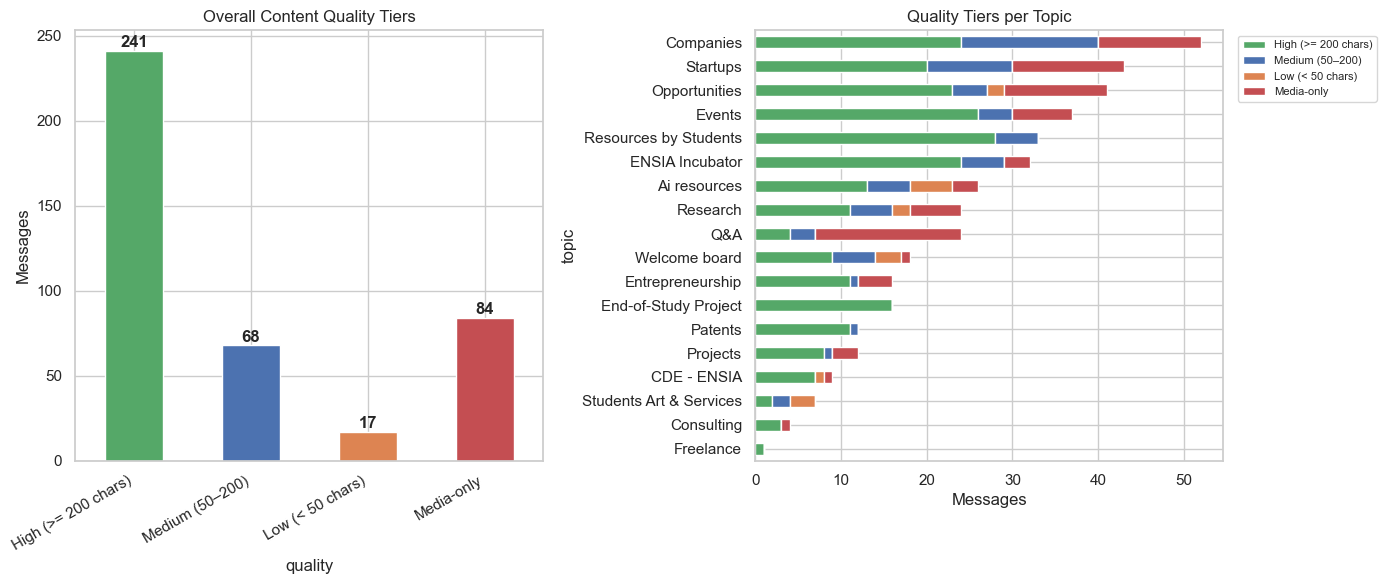


Quality summary:
  High (>= 200 chars): 241 (59%)
  Medium (50–200): 68 (17%)
  Low (< 50 chars): 17 (4%)
  Media-only: 84 (20%)
  Empty: 0 (0%)


In [19]:
def classify_quality(row):
    if row["text_length"] == 0 and (row["has_photo"] or row["has_file"]):
        return "Media-only"
    if row["text_length"] == 0:
        return "Empty"
    if row["text_length"] < 50:
        return "Low (< 50 chars)"
    if row["text_length"] < 200:
        return "Medium (50–200)"
    return "High (>= 200 chars)"

df["quality"] = df.apply(classify_quality, axis=1)

tier_order = ["High (>= 200 chars)", "Medium (50–200)", "Low (< 50 chars)", "Media-only", "Empty"]
tier_colors = {"High (>= 200 chars)": "#55A868", "Medium (50–200)": "#4C72B0",
               "Low (< 50 chars)": "#DD8452", "Media-only": "#C44E52", "Empty": "#8172B3"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall quality distribution
quality_counts = df["quality"].value_counts().reindex(tier_order).dropna()
quality_counts.plot.bar(ax=axes[0], color=[tier_colors[t] for t in quality_counts.index])
axes[0].set_title("Overall Content Quality Tiers")
axes[0].set_ylabel("Messages")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(quality_counts.values):
    axes[0].text(i, v + 2, str(int(v)), ha="center", fontweight="bold")

# Quality per topic (stacked)
if len(topic_df) > 0:
    topic_quality = pd.crosstab(df["topic"], df["quality"])
    topic_quality = topic_quality.reindex(columns=tier_order).dropna(axis=1, how="all")
    topic_quality = topic_quality.loc[topic_quality.sum(axis=1).sort_values(ascending=True).index]
    topic_quality.plot.barh(stacked=True, ax=axes[1],
                            color=[tier_colors.get(c, "#999") for c in topic_quality.columns])
    axes[1].set_title("Quality Tiers per Topic")
    axes[1].set_xlabel("Messages")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print("\nQuality summary:")
for tier in tier_order:
    count = (df["quality"] == tier).sum()
    pct = count / len(df) * 100
    print(f"  {tier}: {count} ({pct:.0f}%)")

## 9. Chatbot Preprocessing Summary

Actionable findings and next steps for building the chatbot knowledge base.

In [20]:
# Final summary statistics
print("=" * 70)
print("ENSIA IMPACT CHATBOT — DATA READINESS REPORT")
print("=" * 70)

total = len(df)
high_q = (df["quality"] == "High (>= 200 chars)").sum()
med_q = (df["quality"] == "Medium (50–200)").sum()
low_q = (df["quality"] == "Low (< 50 chars)").sum()
media_only = (df["quality"] == "Media-only").sum()
empty = (df["quality"] == "Empty").sum()

print(f"\n1. CONTENT VOLUME")
print(f"   Total content messages: {total}")
print(f"   Chatbot-ready (high + medium quality): {high_q + med_q} ({(high_q+med_q)/total*100:.0f}%)")
print(f"   Low quality / noise: {low_q + empty} ({(low_q+empty)/total*100:.0f}%)")
print(f"   Media-dependent (needs OCR/extraction): {media_only} ({media_only/total*100:.0f}%)")

print(f"\n2. TOPIC COVERAGE")
assigned = df["topic"].notna().sum()
print(f"   Messages assigned to a topic: {assigned} ({assigned/total*100:.0f}%)")
print(f"   Unassigned messages: {total - assigned}")
print(f"   Topics with >= 10 messages: {(topic_stats['messages'] >= 10).sum()}")
print(f"   Topics with < 5 messages: {(topic_stats['messages'] < 5).sum()} (consider merging or special handling)")
photo_heavy_topics = topic_stats[topic_stats["photo_pct"] > 50].index.tolist()
if photo_heavy_topics:
    print(f"   Photo-heavy topics needing OCR: {', '.join(photo_heavy_topics)}")

print(f"\n3. LANGUAGES (chat messages)")
for lang, count in df["language"].value_counts().items():
    print(f"   {lang}: {count} ({count/total*100:.0f}%)")
print(f"   Note: PDFs in data/ contain heavy French and Arabic content not reflected here.")

print(f"\n4. MEDIA & FILES")
print(f"   Photos: {df['has_photo'].sum()} (photo-only without text caption: {media_only})")
print(f"   Files/PDFs in messages: {df['has_file'].sum()}")
total_chars = df["text_length"].sum()
print(f"   Total text content: {total_chars:,} characters (~{total_chars//5:,} words)")

print(f"\n5. KEY OBSERVATIONS")
print(f"   • Admin accounts produce ~90% of content — high-authority data, well-curated")
print(f"   • 80% of messages received reactions (median: 11) — engaged community")
print(f"   • Top reactions go to celebratory/holiday messages (Eid greetings),")
print(f"     so reaction count is NOT a clean proxy for informational value")
print(f"   • Q&A topic is mostly photo-driven — limited use without OCR")
print(f"   • Strongest topical areas: {', '.join(topic_stats.head(5).index.tolist())}")

print(f"\n6. PREPROCESSING REQUIRED")
print(f"   a) Flatten polymorphic text field (str vs list of entities) — done in this EDA")
print(f"   b) Resolve topic for {total - assigned} unassigned messages via reply chain — done")
print(f"   c) Extract text from 12 PDFs (Arabic/French support needed)")
print(f"   d) Decide on {media_only} photo-only messages: OCR (recommended for Q&A) or discard")
print(f"   e) Tag languages for multilingual retrieval")
print(f"   f) Concatenate threaded replies for context (~58 reply messages need parent context)")
print(f"   g) Filter holiday/greeting messages from training (low informational value)")

print(f"\n7. CHATBOT KNOWLEDGE BASE ESTIMATE")
usable = high_q + med_q
print(f"   ~{usable} text messages ready for indexing")
print(f"   ~12 PDF documents to extract and index (substantial French/Arabic content)")
print(f"   Covering {len(topic_stats)} distinct topic areas")
print(f"   Strongest areas: {', '.join(topic_stats.head(5).index.tolist())}")
print(f"   Weakest areas: {', '.join(topic_stats[topic_stats['messages'] < 5].index.tolist()) or 'N/A'}")

ENSIA IMPACT CHATBOT — DATA READINESS REPORT

1. CONTENT VOLUME
   Total content messages: 410
   Chatbot-ready (high + medium quality): 309 (75%)
   Low quality / noise: 17 (4%)
   Media-dependent (needs OCR/extraction): 84 (20%)

2. TOPIC COVERAGE
   Messages assigned to a topic: 407 (99%)
   Unassigned messages: 3
   Topics with >= 10 messages: 14
   Topics with < 5 messages: 2 (consider merging or special handling)
   Photo-heavy topics needing OCR: Opportunities, Events, Q&A

3. LANGUAGES (chat messages)
   English: 311 (76%)
   empty: 84 (20%)
   Arabic: 14 (3%)
   French: 1 (0%)
   Note: PDFs in data/ contain heavy French and Arabic content not reflected here.

4. MEDIA & FILES
   Photos: 135 (photo-only without text caption: 84)
   Files/PDFs in messages: 13
   Total text content: 116,594 characters (~23,318 words)

5. KEY OBSERVATIONS
   • Admin accounts produce ~90% of content — high-authority data, well-curated
   • 80% of messages received reactions (median: 11) — engaged c